### Instrucciones 

- **Instrucción:** Abre el archivo `datos_ejercicioRidge0403.xlsx` que se te ha proporcionado.  
- **Instrucción:** Ejecuta el código de la sección 2. Se te pedirá que ingreses dos parámetros:  
  1. **Orden del polinomio:** Este parámetro define la complejidad del modelo que deseas ajustar. Por ejemplo, un orden mayor puede permitirte modelar comportamientos más complejos, pero cuidado, un orden muy alto puede llevar a sobreajuste.  
  2. **Valor de lambda para la regularización:** Este parámetro se utiliza para controlar la magnitud de los coeficientes en un modelo Ridge. Si no deseas aplicar regularización, ingresa 0.  
- **Instrucción:** Observa la gráfica que se genera y analiza cómo se ajusta el modelo a los datos de entrenamiento.  
- **Instrucción:** Experimenta con distintos valores de orden y lambda para ver cómo varían los coeficientes y el comportamiento del modelo.

Estos ejercicios te ayudarán a comprender el efecto del orden del polinomio y de la regularización en el sobreajuste y la capacidad de generalización de un modelo.



ALUMNO: Ingresa el orden del polinomio que deseas usar:  3
ALUMNO: Ingresa el valor de lambda para la regularización Ridge (0 para OLS):  0.1



Resultados en el conjunto de entrenamiento:
MSE - Modelo OLS (sin regularización): 0.343
MSE - Modelo Ridge (con regularización): 0.354

Resultados en el conjunto de prueba:
MSE - Modelo OLS (sin regularización): 0.765
MSE - Modelo Ridge (con regularización): 0.799


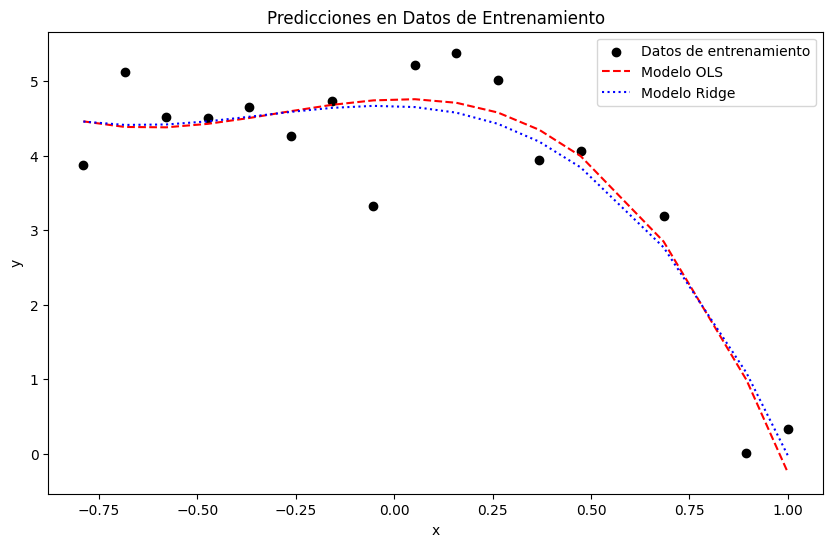

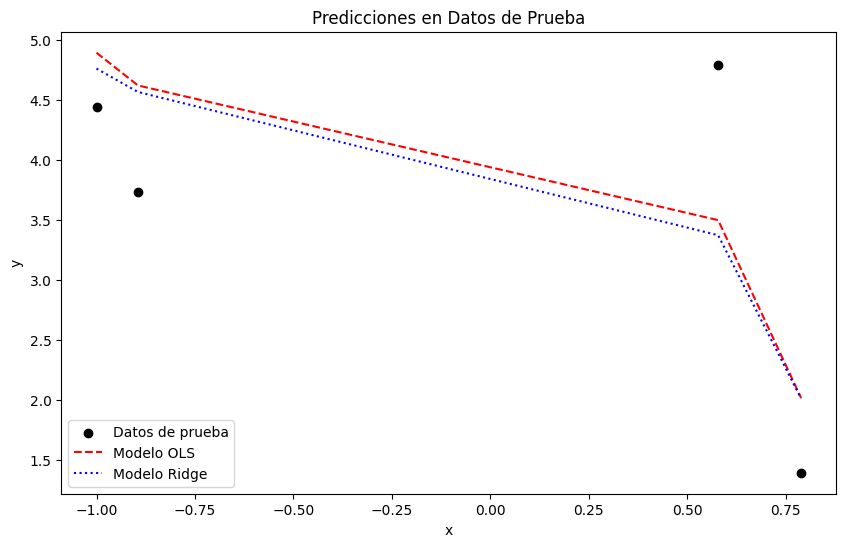

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# ================================================================
# 1. Importar datos desde Excel (archivo "datos_ejercicioRidge0403.xlsx" proporcionado)
# ================================================================
data = pd.read_excel("datos_ejercicioRidge0403.xlsx")
x_all = data["x"].values
y_all = data["y"].values

# Dividir datos en entrenamiento (70%) y prueba (30%)
x_train, x_test, y_train, y_test = train_test_split(x_all, y_all, test_size=0.2, random_state=42)

# ================================================================
# 2. Funciones auxiliares
# ================================================================
def design_matrix(x, degree):
    """
    Crea la matriz de diseño para un polinomio de grado 'degree'.
    Cada fila es [1, x, x^2, ..., x^(degree)].
    """
    return np.vander(x, N=degree+1, increasing=True)

def ols_weights(X, y):
    """
    Calcula los pesos usando mínimos cuadrados ordinarios.
    Se utiliza la pseudoinversa para mayor estabilidad numérica.
    """
    return np.linalg.pinv(X.T @ X) @ X.T @ y

def ridge_weights(X, y, lam):
    """
    Calcula los pesos para regresión Ridge.
    Se utiliza la pseudoinversa para mayor estabilidad numérica.
    """
    d = X.shape[1]
    return np.linalg.pinv(X.T @ X + lam * np.eye(d)) @ X.T @ y

# ================================================================
# 3. Parámetros a definir por el alumno
# ================================================================
# ALUMNO: Ingresa el orden del polinomio que deseas usar (por ejemplo, 4, 5, 8, etc.).
degree = int(input("ALUMNO: Ingresa el orden del polinomio que deseas usar: "))   #  O c h o

# ALUMNO: Ingresa el valor de lambda para la regularización Ridge.
# Si no deseas aplicar regularización, ingresa 0.
lam = float(input("ALUMNO: Ingresa el valor de lambda para la regularización Ridge (0 para OLS): "))  # u n o

# ================================================================
# 4. Ajuste de dos modelos (sin y con regularización)
# ================================================================
# Construir las matrices de diseño para entrenamiento y prueba
X_train = design_matrix(x_train, degree)
X_test = design_matrix(x_test, degree)

# Modelo 1: OLS (sin regularización)
w_ols = ols_weights(X_train, y_train)
y_pred_ols = X_test @ w_ols
y_train_pred_ols = X_train @ w_ols  # Predicción en entrenamiento

# Modelo 2: Ridge (con regularización)
# Si lam es 0, ambos modelos serán idénticos.
w_ridge = ridge_weights(X_train, y_train, lam) if lam > 0 else w_ols.copy()
y_pred_ridge = X_test @ w_ridge
y_train_pred_ridge = X_train @ w_ridge  # Predicción en entrenamiento

# ================================================================
# 5. Cálculo del error: MSE para entrenamiento y prueba
# ================================================================
mse_test_ols = mean_squared_error(y_test, y_pred_ols)
mse_test_ridge = mean_squared_error(y_test, y_pred_ridge)

mse_train_ols = mean_squared_error(y_train, y_train_pred_ols)
mse_train_ridge = mean_squared_error(y_train, y_train_pred_ridge)

print("\nResultados en el conjunto de entrenamiento:")
print("MSE - Modelo OLS (sin regularización): {:.3f}".format(mse_train_ols))
print("MSE - Modelo Ridge (con regularización): {:.3f}".format(mse_train_ridge))

print("\nResultados en el conjunto de prueba:")
print("MSE - Modelo OLS (sin regularización): {:.3f}".format(mse_test_ols))
print("MSE - Modelo Ridge (con regularización): {:.3f}".format(mse_test_ridge))

# ================================================================
# 6. Graficar las predicciones en datos de entrenamiento
# ================================================================
y_train_pred_ols = X_train @ w_ols
y_train_pred_ridge = X_train @ w_ridge

plt.figure(figsize=(10,6))
plt.scatter(x_train, y_train, color="black", label="Datos de entrenamiento")
idx_sort_train = np.argsort(x_train)
plt.plot(x_train[idx_sort_train], y_train_pred_ols[idx_sort_train], color="red", linestyle="--", label="Modelo OLS")
plt.plot(x_train[idx_sort_train], y_train_pred_ridge[idx_sort_train], color="blue", linestyle=":", label="Modelo Ridge")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Predicciones en Datos de Entrenamiento")
plt.legend()
plt.show()


# ================================================================
# 7. Graficar las predicciones en datos de prueba
# ================================================================
plt.figure(figsize=(10,6))
plt.scatter(x_test, y_test, color="black", label="Datos de prueba")
# Ordenamos los datos para graficar líneas suaves
idx_sort = np.argsort(x_test)
plt.plot(x_test[idx_sort], y_pred_ols[idx_sort], color="red", linestyle="--", label="Modelo OLS")
plt.plot(x_test[idx_sort], y_pred_ridge[idx_sort], color="blue", linestyle=":", label="Modelo Ridge")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Predicciones en Datos de Prueba")
plt.legend()
plt.show()



In [6]:
# Tabla de resultados con diferentes grados y lambdas de ridge
resultaos = pd.DataFrame(columns=[ "grado", "lambda", "MSE_entrenamiento_OLS", "MSE_entrenamiento_ridge", "MSE_prueba_OLS", "MSE_prueba_ridge" ])
for degree in range(1, 11):
    for lam in np.arange(0, 1, 0.01):
        x_train, x_test, y_train, y_test = train_test_split(x_all, y_all, test_size=0.2, random_state=42)
        X_train = design_matrix(x_train, degree)
        X_test = design_matrix(x_test, degree)
        
        # Modelo 1: OLS (sin regularización)
        w_ols = ols_weights(X_train, y_train)
        y_pred_ols = X_test @ w_ols
        y_train_pred_ols = X_train @ w_ols  # Predicción en entrenamiento
        
        # Modelo 2: Ridge (con regularización)
        # Si lam es 0, ambos modelos serán idénticos.
        w_ridge = ridge_weights(X_train, y_train, lam) if lam > 0 else w_ols.copy()
        y_pred_ridge = X_test @ w_ridge
        y_train_pred_ridge = X_train @ w_ridge  # Predicción en entrenamiento
        
        # ================================================================
        # 5. Cálculo del error: MSE para entrenamiento y prueba
        # ================================================================
        mse_test_ols = mean_squared_error(y_test, y_pred_ols)
        mse_test_ridge = mean_squared_error(y_test, y_pred_ridge)
        
        mse_train_ols = mean_squared_error(y_train, y_train_pred_ols)
        mse_train_ridge = mean_squared_error(y_train, y_train_pred_ridge)
        
        # ================================================================
        # 6. Graficar las predicciones en datos de entrenamiento
        # ================================================================
        y_train_pred_ols = X_train @ w_ols
        y_train_pred_ridge = X_train @ w_ridge

        # Añadir a resultados
        resultaos_iter = pd.Series(
        {
            "grado": degree, 
            "lambda": lam,
            "MSE_entrenamiento_OLS": mse_train_ols,
            "MSE_entrenamiento_ridge": mse_train_ridge,
            "MSE_prueba_OLS": mse_test_ols,
            "MSE_prueba_ridge": mse_test_ridge
        })
        resultaos = pd.concat([ resultaos, resultaos_iter.to_frame().T ], ignore_index=True)

# Al final, guardo a CSV para pegar en Excel
resultaos.to_csv("resultaos.csv")
